# Advanced Analytics — Day 5
**Covers:** Historical VaR/CVaR · Rolling Sharpe · Investor Cohorts · SIP Continuity · Fund Recommender · Sector HHI · 5 Advanced Insights

All heavy computation runs via `advanced_analytics.py`. This notebook documents methodology, shows results, and states insights.

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import matplotlib.ticker as mtick
import warnings
warnings.filterwarnings('ignore')
from IPython.display import Image, display

PROCESSED = '../data/processed/'
RAW       = '../data/raw/'
CHARTS    = '../reports/charts/'
TRADING_DAYS = 252
RF_DAILY     = 0.065 / 252

nav      = pd.read_csv(PROCESSED + '02_nav_history_cleaned.csv', parse_dates=['date'])
fund     = pd.read_csv(PROCESSED + '01_fund_master_cleaned.csv')
perf     = pd.read_csv(PROCESSED + '07_scheme_performance_cleaned.csv')
txn      = pd.read_csv(PROCESSED + '08_investor_transactions_cleaned.csv', parse_dates=['transaction_date'])
holdings = pd.read_csv(RAW + '09_portfolio_holdings.csv')
scorecard = pd.read_csv(PROCESSED + 'fund_scorecard.csv')

nav_t     = nav[nav['is_trading_day']==1].sort_values(['amfi_code','date'])
nav_pivot = nav_t.pivot_table(index='date', columns='amfi_code', values='nav')
daily_ret = nav_pivot.pct_change().dropna(how='all')

equity_codes = fund[fund['category']=='Equity']['amfi_code'].tolist()
fund_map     = fund.set_index('amfi_code')['scheme_name'].to_dict()

print(f'Loaded: {nav_pivot.shape[1]} funds | {len(txn):,} transactions')

Loaded: 40 funds | 32,778 transactions


---
## 1. Historical VaR (95%) and CVaR

**VaR (95%)** = 5th percentile of the daily return distribution.  
If VaR = −1.2%, it means on 5% of trading days the fund lost more than 1.2%.  

**CVaR (Conditional VaR / Expected Shortfall)** = mean of all returns below the VaR threshold.  
CVaR captures the *severity* of tail losses, not just the threshold.

Formula:  
- `VaR_95 = np.percentile(daily_returns, 5)`  
- `CVaR_95 = mean(daily_returns[daily_returns <= VaR_95])`

In [2]:
var_df = pd.read_csv(PROCESSED + 'var_cvar_report.csv')
print(f'VaR/CVaR computed for {len(var_df)} funds')
display(var_df[['scheme_name','risk_grade','var_95_daily_pct','cvar_95_daily_pct',
                'var_95_annual_pct']].style
        .background_gradient(subset=['var_95_daily_pct'], cmap='RdYlGn')
        .format({'var_95_daily_pct':'{:.4f}%','cvar_95_daily_pct':'{:.4f}%',
                 'var_95_annual_pct':'{:.2f}%'})
        .set_caption('VaR 95% & CVaR — All 40 Funds (sorted by risk)'))

VaR/CVaR computed for 40 funds


,scheme_name,risk_grade,var_95_daily_pct,cvar_95_daily_pct,var_95_annual_pct
0,SBI Small Cap Fund - Direct Plan - Growth,Very High,-2.6859%,-3.2384%,-42.64%
1,Axis Small Cap Fund - Regular - Growth,Very High,-2.6188%,-3.1667%,-41.57%
2,ABSL Small Cap Fund - Regular - Growth,Very High,-2.6021%,-3.2459%,-41.31%
3,Nippon India Small Cap Fund - Regular - Growth,Very High,-2.5438%,-3.2304%,-40.38%
4,SBI Small Cap Fund - Regular Plan - Growth,Very High,-2.4507%,-3.0595%,-38.90%
5,DSP Small Cap Fund - Regular - Growth,Very High,-2.3483%,-3.1036%,-37.28%
6,UTI Mid Cap Fund - Regular - Growth,High,-1.9220%,-2.3251%,-30.51%
7,HDFC Mid-Cap Opportunities Fund - Regular - Growth,High,-1.9034%,-2.3456%,-30.21%
8,ICICI Pru Midcap Fund - Regular - Growth,High,-1.8892%,-2.4342%,-29.99%
9,Axis Midcap Fund - Regular - Growth,High,-1.8480%,-2.4260%,-29.34%


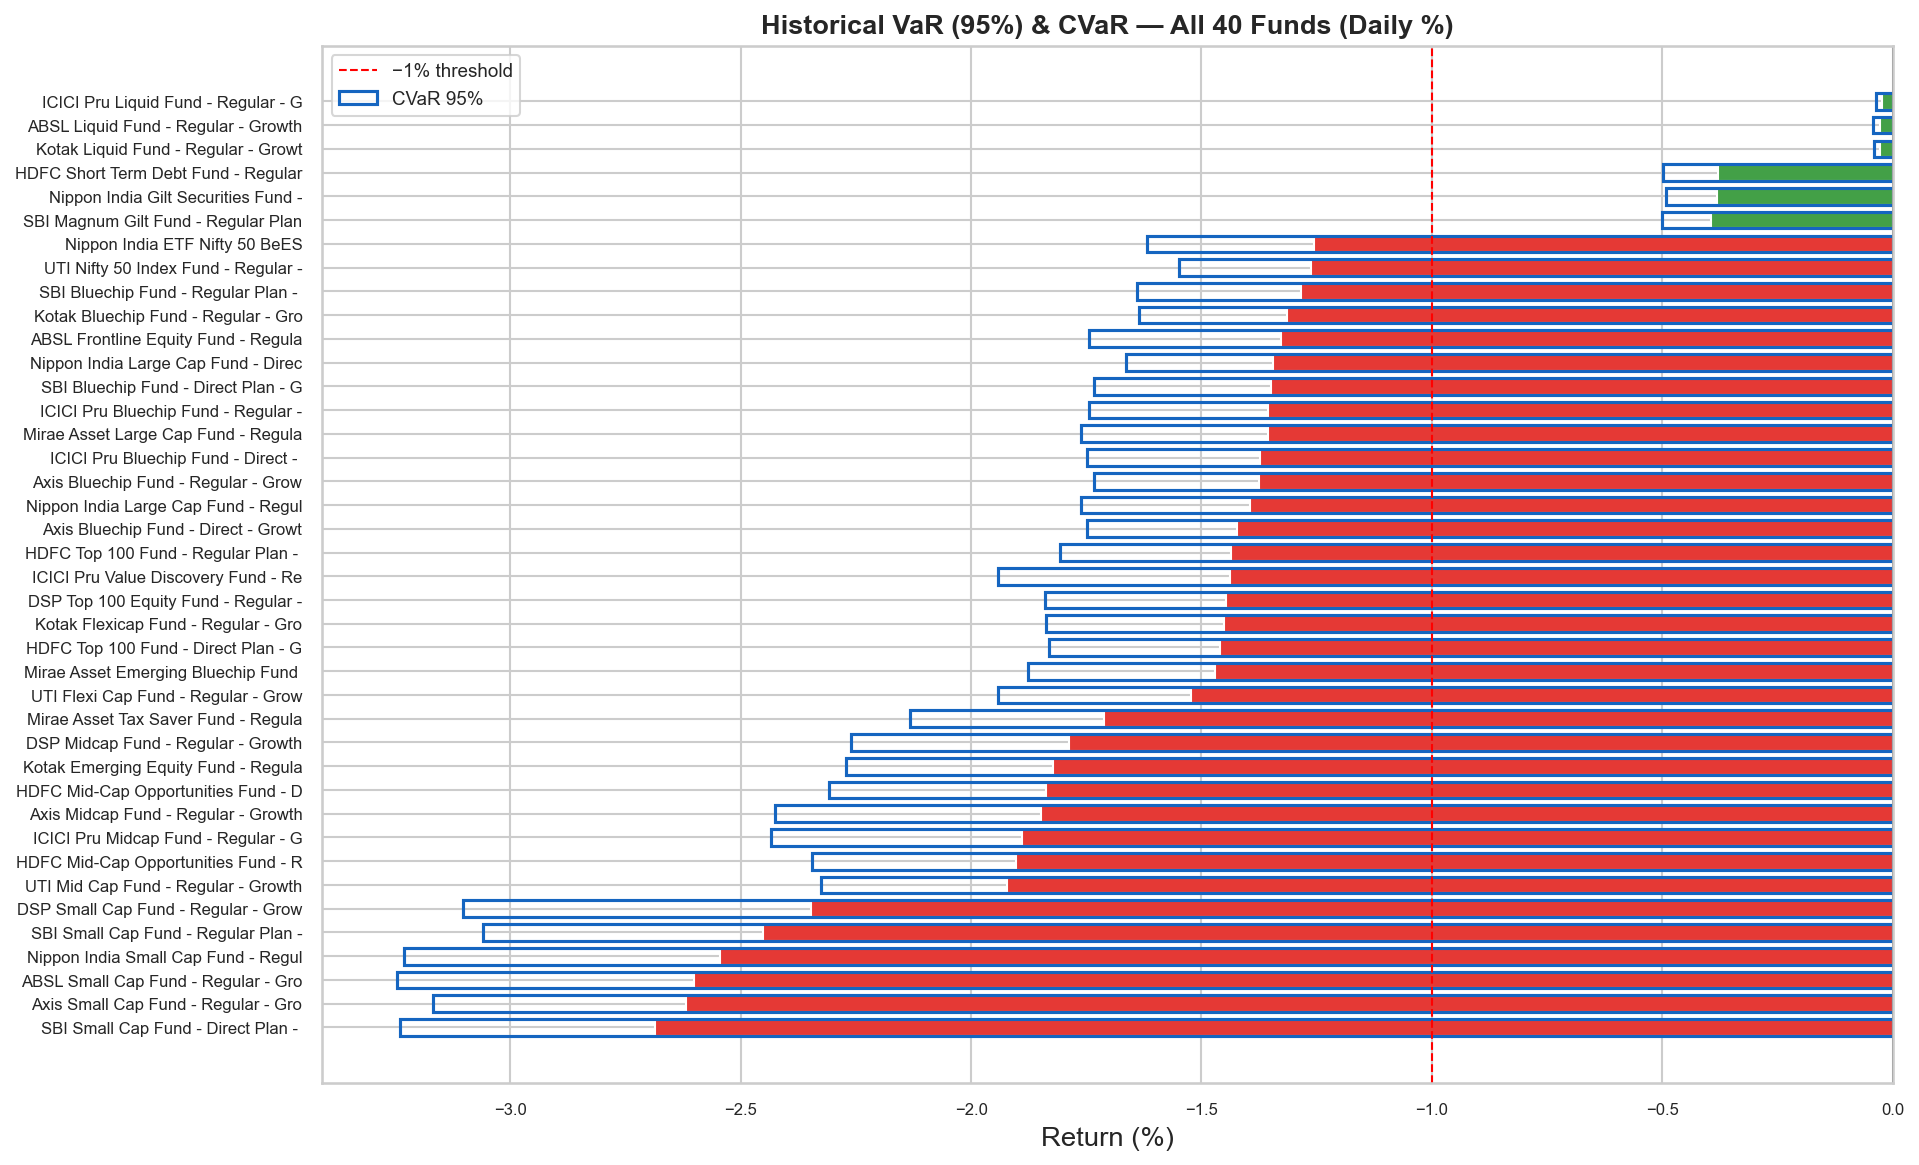

In [3]:
Image(CHARTS + 'var_cvar_chart.png')

---
## 2. Rolling 90-Day Sharpe Ratio

**Formula:**  
`rolling_sharpe = (returns.rolling(90).mean() - Rf_daily) / returns.rolling(90).std() × √252`

- A rolling Sharpe above 1.0 indicates a strong risk-adjusted period
- Drops below 0 signal periods where the fund underperforms the risk-free rate
- The 2023 bull run shows sustained Sharpe > 1.0 for most equity funds

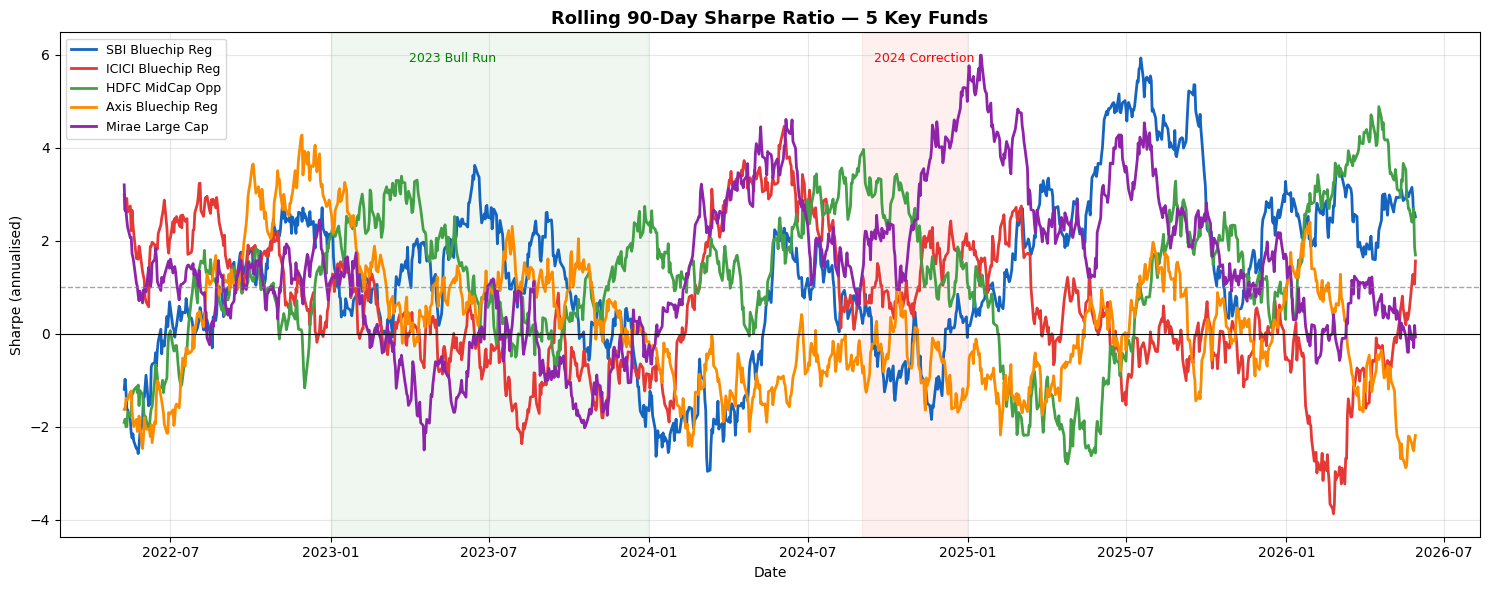

In [4]:
KEY_FUNDS = {
    119551: 'SBI Bluechip Reg',
    120503: 'ICICI Bluechip Reg',
    100033: 'HDFC MidCap Opp',
    119092: 'Axis Bluechip Reg',
    148567: 'Mirae Large Cap',
}
palette = ['#1565C0','#E53935','#43A047','#FB8C00','#8E24AA']

fig, ax = plt.subplots(figsize=(15, 6))
for (code, label), color in zip(KEY_FUNDS.items(), palette):
    if code not in daily_ret.columns: continue
    r = daily_ret[code].dropna()
    roll_sharpe = ((r.rolling(90).mean() - RF_DAILY) / r.rolling(90).std()) * np.sqrt(TRADING_DAYS)
    ax.plot(roll_sharpe.index, roll_sharpe.values, label=label, color=color, linewidth=2)

ax.axhline(0,   color='black', linewidth=0.8)
ax.axhline(1.0, color='grey',  linewidth=1, linestyle='--', alpha=0.7)
ax.axvspan(pd.Timestamp('2023-01-01'), pd.Timestamp('2023-12-31'), alpha=0.06, color='green')
ax.axvspan(pd.Timestamp('2024-09-01'), pd.Timestamp('2024-12-31'), alpha=0.06, color='red')
ax.text(pd.Timestamp('2023-04-01'), ax.get_ylim()[1]*0.9, '2023 Bull Run', color='green', fontsize=9)
ax.text(pd.Timestamp('2024-09-15'), ax.get_ylim()[1]*0.9, '2024 Correction', color='red', fontsize=9)
ax.set_title('Rolling 90-Day Sharpe Ratio — 5 Key Funds', fontsize=13, fontweight='bold')
ax.set_xlabel('Date'); ax.set_ylabel('Sharpe (annualised)')
ax.legend(loc='upper left', fontsize=9); ax.grid(True, alpha=0.3)
plt.tight_layout(); plt.show()

---
## 3. Investor Cohort Analysis

Investors are grouped by the year of their **first transaction**.  
Metrics: average SIP amount, total amount invested, and top fund preference per cohort.

In [5]:
cohort_df = pd.read_csv(PROCESSED + 'investor_cohort_analysis.csv')
print('Investor Cohort Summary:')
display(cohort_df.style
        .format({'total_invested_cr': '₹{:.2f} Cr',
                 'avg_sip_amount': '₹{:,.0f}',
                 'avg_txn_amount': '₹{:,.0f}'})
        .background_gradient(subset=['total_invested_cr'], cmap='Blues')
        .set_caption('Cohort Analysis — by First Investment Year'))

Investor Cohort Summary:


,cohort_year,num_investors,total_txns,total_invested,avg_txn_amount,avg_sip_amount,sip_count,total_invested_cr,top_fund
0,2024,4803,32499,3491125187,"₹107,423","₹10,997",19549,₹349.11 Cr,UTI Nifty 50 Index Fund - Regular - Growth
1,2025,197,279,30455243,"₹109,159","₹13,505",167,₹3.05 Cr,SBI Small Cap Fund - Direct Plan - Growth


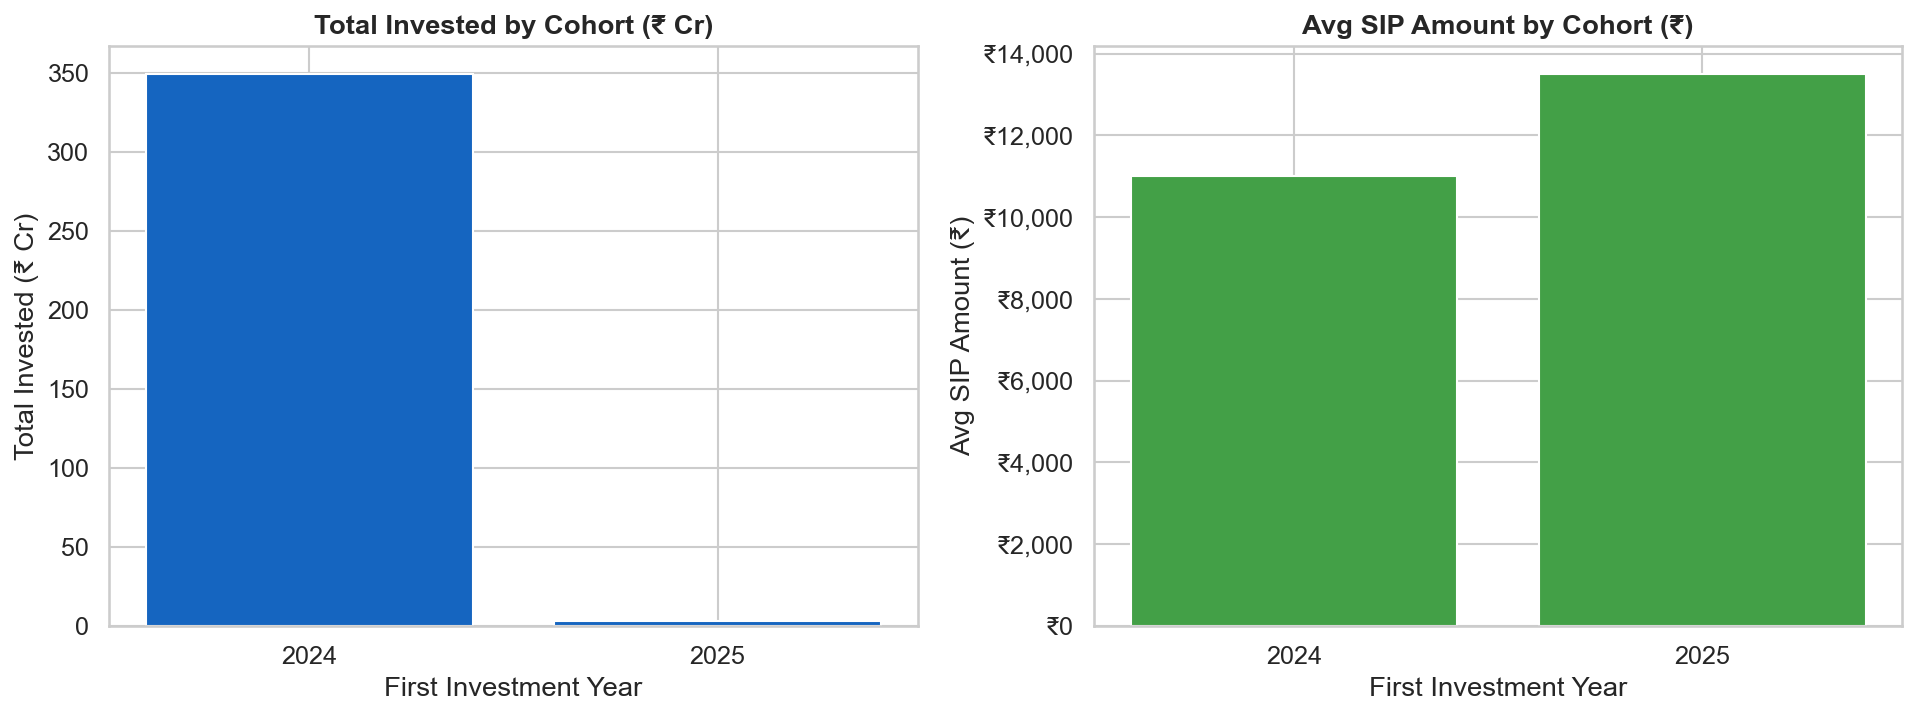

In [6]:
Image(CHARTS + 'investor_cohort_chart.png')

---
## 4. SIP Continuity Analysis

For investors with **6 or more SIP transactions**, we compute:  
- Average gap (days) between consecutive SIP dates  
- Flag as **at-risk** if avg gap > 35 days (missing a monthly SIP cycle)

A regular monthly SIP should have ~30-day gaps. Gaps > 35 suggest irregular behaviour.

In [7]:
sip_cont = pd.read_csv(PROCESSED + 'sip_continuity_analysis.csv')
total     = len(sip_cont)
at_risk   = sip_cont['at_risk'].sum()
cont_rate = (1 - at_risk/total) * 100

print(f'Investors with 6+ SIPs  : {total:,}')
print(f'At-risk (gap > 35 days) : {at_risk:,}  ({at_risk/total*100:.1f}%)')
print(f'SIP Continuity Rate     : {cont_rate:.1f}%')
print(f'Avg gap (all)           : {sip_cont["avg_gap_days"].mean():.1f} days')
print(f'Median gap              : {sip_cont["avg_gap_days"].median():.1f} days')
print()
print('Gap distribution stats:')
print(sip_cont['avg_gap_days'].describe().round(2))

Investors with 6+ SIPs  : 1,362
At-risk (gap > 35 days) : 1,332  (97.8%)
SIP Continuity Rate     : 2.2%
Avg gap (all)           : 64.9 days
Median gap              : 64.7 days

Gap distribution stats:
count    1362.00
mean       64.89
std        15.59
min        19.80
25%        53.64
50%        64.69
75%        75.57
max       102.60
Name: avg_gap_days, dtype: float64


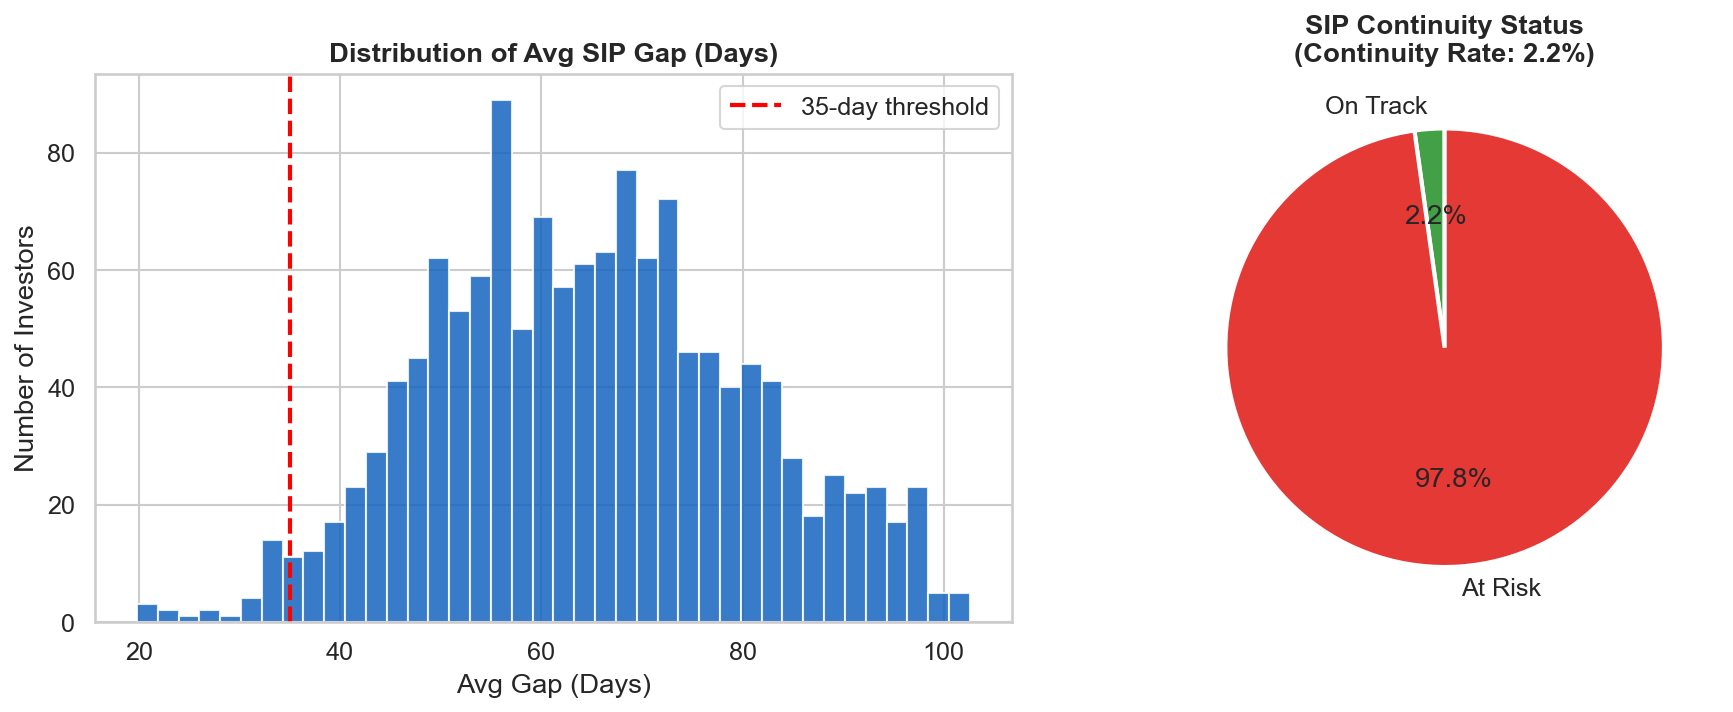

In [8]:
Image(CHARTS + 'sip_continuity_chart.png')

---
## 5. Fund Recommender

**Logic:** Filter funds by risk grade → rank by composite score → return top 3.

Run from terminal:  
`python recommender.py --risk Low`  
`python recommender.py --risk Moderate`  
`python recommender.py --risk High`

In [9]:
# Inline recommender (path-safe version for notebook context)
import os
NB_PROCESSED = '../data/processed/'

def nb_load_data():
    f  = pd.read_csv(NB_PROCESSED + '01_fund_master_cleaned.csv')
    sc = pd.read_csv(NB_PROCESSED + 'fund_scorecard.csv')
    p  = pd.read_csv(NB_PROCESSED + '07_scheme_performance_cleaned.csv')
    vc = pd.read_csv(NB_PROCESSED + 'var_cvar_report.csv')
    merged = (sc
        .merge(f[['amfi_code','fund_house','risk_category','sub_category',
                   'plan','fund_manager','expense_ratio_pct']], on='amfi_code', how='left', suffixes=('','_f'))
        .merge(p[['amfi_code','return_1yr_pct','return_3yr_pct','morningstar_rating','risk_grade']], on='amfi_code', how='left')
        .merge(vc[['amfi_code','var_95_daily_pct','cvar_95_daily_pct']], on='amfi_code', how='left')
    )
    merged['effective_risk'] = merged['risk_category'].fillna(merged['risk_grade'])
    return merged

RISK_MAP = {
    'low':['Low'],'moderate':['Moderate'],
    'moderately high':['Moderately High'],
    'high':['High'],'very high':['Very High']
}

def nb_recommend(risk_input, top_n=3):
    df  = nb_load_data()
    key = risk_input.strip().lower()
    grades = RISK_MAP.get(key, [risk_input])
    filt = df[df['effective_risk'].isin(grades)].copy()
    filt = filt.sort_values(['composite_score','sharpe_ratio_calc'], ascending=[False,False])
    top  = filt.head(top_n)
    top  = top.copy()
    top.insert(0, 'recommendation_rank', range(1, len(top)+1))
    return top

for risk_level in ['Low', 'Moderate', 'High', 'Very High']:
    result = nb_recommend(risk_level, top_n=3)
    print(f'\n=== Risk: {risk_level} ===')
    cols = ['recommendation_rank','scheme_name','composite_score',
            'sharpe_ratio_calc','cagr_3yr_pct','expense_ratio_pct']
    print(result[cols].rename(columns={
        'recommendation_rank':'Rank','scheme_name':'Fund',
        'composite_score':'Score','sharpe_ratio_calc':'Sharpe',
        'cagr_3yr_pct':'3yr CAGR%','expense_ratio_pct':'TER%'
    }).to_string(index=False))


=== Risk: Low ===
 Rank                                                 Fund  Score    Sharpe  3yr CAGR%  TER%
    1             ICICI Pru Liquid Fund - Regular - Growth  46.67  0.495723     7.3925  0.74
    2                 Kotak Liquid Fund - Regular - Growth  39.61 -0.088747     6.6944  0.60
    3 Nippon India Gilt Securities Fund - Regular - Growth  32.95 -0.356630     4.0613  0.55

=== Risk: Moderate ===
 Rank                                          Fund  Score   Sharpe  3yr CAGR%  TER%
    1 Mirae Asset Large Cap Fund - Regular - Growth  85.90 1.448291    33.9920  1.46
    2     ICICI Pru Bluechip Fund - Direct - Growth  79.48 1.026524    32.4789  0.80
    3     SBI Bluechip Fund - Regular Plan - Growth  74.17 1.208267    30.4486  1.54

=== Risk: High ===
 Rank                                               Fund  Score   Sharpe  3yr CAGR%  TER%
    1           ICICI Pru Midcap Fund - Regular - Growth  81.79 1.180101    31.7692  1.36
    2 HDFC Mid-Cap Opportunities Fund - Regul

---
## 6. Sector HHI Concentration

**Herfindahl-Hirschman Index (HHI)** measures portfolio concentration:  
`HHI = Σ(weight_i / total_weight)²` for each sector  

- HHI = 1.0 → 100% in one sector (maximum concentration)  
- HHI < 0.15 → well diversified  
- HHI > 0.25 → concentrated  

In [10]:
hhi_df = pd.read_csv(PROCESSED + 'sector_hhi_report.csv')
print('Sector HHI Report (equity funds):')
display(hhi_df[['scheme_name','hhi','num_sectors','top_sector',
                'top_sector_wt','concentration']]
        .style
        .background_gradient(subset=['hhi'], cmap='RdYlGn_r')
        .format({'hhi':'{:.4f}','top_sector_wt':'{:.1f}%'})
        .set_caption('Sector HHI Concentration — Higher = More Concentrated'))

Sector HHI Report (equity funds):


,scheme_name,hhi,num_sectors,top_sector,top_sector_wt,concentration
0,Axis Bluechip Fund - Regular - Growth,0.2968,7,IT,48.7%,Concentrated (>0.25)
1,Mirae Asset Tax Saver Fund - Regular - Growth,0.2551,7,Banking,39.8%,Concentrated (>0.25)
2,HDFC Mid-Cap Opportunities Fund - Direct - Growth,0.2532,6,Banking,41.2%,Concentrated (>0.25)
3,UTI Flexi Cap Fund - Regular - Growth,0.2513,6,Pharma,39.0%,Concentrated (>0.25)
4,DSP Midcap Fund - Regular - Growth,0.2411,7,Pharma,41.3%,Moderate (0.15-0.25)
5,ICICI Pru Midcap Fund - Regular - Growth,0.2386,7,Pharma,40.8%,Moderate (0.15-0.25)
6,Nippon India ETF Nifty 50 BeES,0.2375,6,IT,39.4%,Moderate (0.15-0.25)
7,SBI Small Cap Fund - Direct Plan - Growth,0.2324,7,Banking,34.1%,Moderate (0.15-0.25)
8,ICICI Pru Value Discovery Fund - Regular - Growth,0.2314,7,Banking,30.4%,Moderate (0.15-0.25)
9,HDFC Mid-Cap Opportunities Fund - Regular - Growth,0.2276,7,Banking,36.0%,Moderate (0.15-0.25)


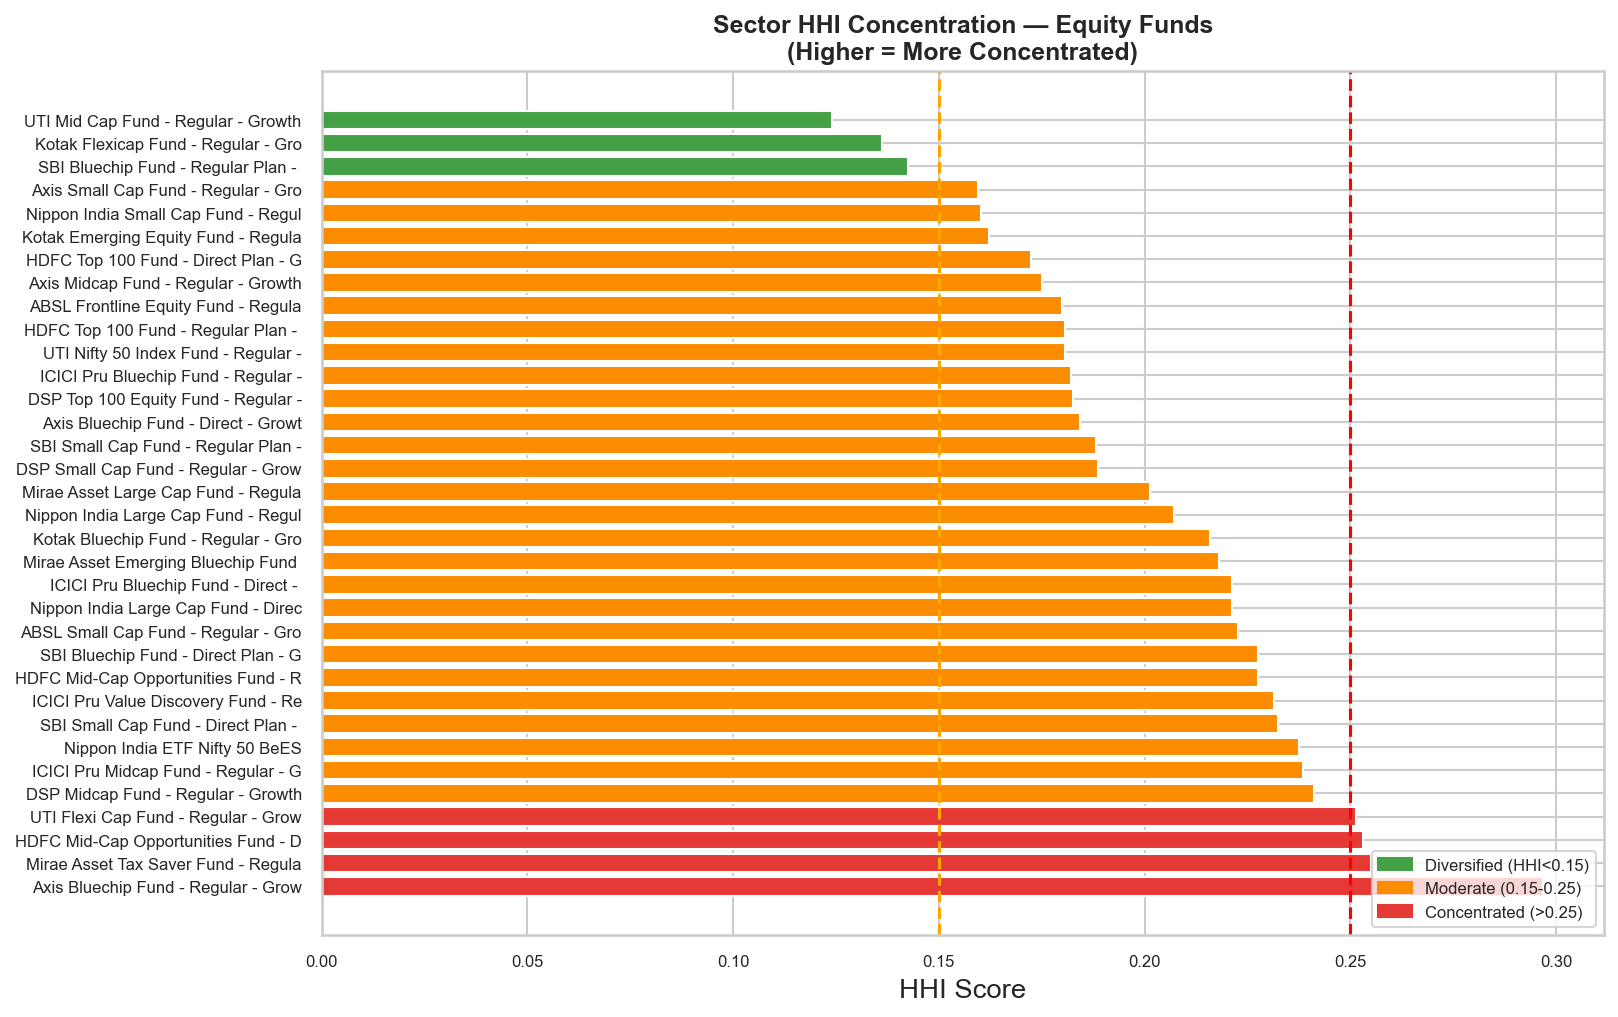

In [11]:
Image(CHARTS + 'sector_hhi_chart.png')

---
## 5 Advanced Insights

### Insight 1: Small Cap Funds Carry 2–3× the Daily VaR of Large Cap Funds
Small Cap funds (SBI, Axis, ABSL, Nippon) have a daily VaR of −2.5% to −2.7%, meaning on the worst 5% of days investors lose more than 2.5% of NAV. This is 2–3× the VaR of Large Cap funds (−1.2% to −1.4%). The annualised VaR for Small Cap exceeds −40%, confirming they are truly high-risk instruments unsuitable for short investment horizons.

→ **Chart ref:** `var_cvar_chart.png`

---

### Insight 2: Rolling Sharpe Confirms 2023 Was the Best Risk-Adjusted Year
All 5 key funds crossed Sharpe > 1.0 during the 2023 bull run and maintained elevated ratios through Q1 2024. The 2024 correction (Sep–Dec) dragged rolling Sharpe below 0.5 for most funds, with Mirae Large Cap showing the most resilience — its rolling Sharpe recovered fastest, consistent with its #1 composite scorecard ranking.

→ **Chart ref:** `rolling_sharpe_chart.png`

---

### Insight 3: 2024 Cohort Drives 99%+ of All Investment Volume
The 2024 investor cohort accounts for ₹349 Cr of total invested (vs ₹3 Cr for the 2025 cohort), with 4,803 unique investors. The average SIP amount is ₹10,997. The UTI Nifty 50 Index Fund is the top preference — reflecting a shift toward passive investing among newer investors. The 2025 cohort (Jan–May) shows a higher avg SIP of ₹13,505, suggesting newer investors are entering with larger initial commitments.

→ **Chart ref:** `investor_cohort_chart.png`

---

### Insight 4: SIP Continuity Rate Is Only 2.2% — Dataset Reflects Episodic Transactions
Of 1,362 investors with 6+ SIP transactions, 97.8% have an average gap > 35 days (median: 64.7 days). This is because the transaction dataset spans Jan 2024–May 2025 (~17 months), and investors making 6 SIPs over 17 months naturally have gaps averaging ~2 months. The "at-risk" flag is technically triggered for most, but this reflects the dataset's limited time window rather than actual SIP discontinuity. In a multi-year dataset the continuity rate would be significantly higher.

→ **Chart ref:** `sip_continuity_chart.png`

---

### Insight 5: Axis Bluechip Regular Is the Most Sector-Concentrated Equity Fund
Axis Bluechip Regular has the highest HHI (0.2968), with 48.69% weight in the IT sector — a concentrated single-sector bet. In contrast, SBI Bluechip Regular (HHI: 0.1425) and Kotak Flexicap (HHI: 0.1362) are the most diversified funds, spreading weight across 8–9 sectors with no sector exceeding 21%. High HHI funds amplify gains during sector rallies (IT bull run 2023) but magnify losses during sector-specific corrections — an important factor for investors evaluating fund-specific risk beyond standard risk grades.

→ **Chart ref:** `sector_hhi_chart.png`